# BuildBots Engagement Analysis (T1–T7)

Explores children's engagement (intrinsic motivation) across the seven BuildBots sessions.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_PATH = "Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv"
TIMEPOINT_ORDER = ["T1", "T2", "T3", "T4", "T5", "T6", "T7"]

# IMI subscales as defined in the codebook
# (Buildbots_Codebook_15122025-2 / Intrinsic motivation inventory-Table 1.csv)
SUBSCALES = {
    "Interest/Enjoyment":    ["IntrinsicMotivation_1", "IntrinsicMotivation_2"],
    "Perceived Competence":  ["IntrinsicMotivation_3", "IntrinsicMotivation_4"],
    "Pressure/Tension":      ["IntrinsicMotivation_5", "IntrinsicMotivation_6"],
    "Value/Usefulness":      ["IntrinsicMotivation_7", "IntrinsicMotivation_8"],
}
ALL_IM_COLS = [col for items in SUBSCALES.values() for col in items]

## Load data

In [8]:
df = pd.read_csv(DATA_PATH, encoding="latin-1")

# Keep only rows with a valid timepoint and numeric group
df = df[df["Timepoint"].isin(TIMEPOINT_ORDER)].copy()
df["Timepoint"] = pd.Categorical(df["Timepoint"], categories=TIMEPOINT_ORDER, ordered=True)
df["Group"] = pd.to_numeric(df["Group"], errors="coerce")

# Convert all IM items to numeric
df[ALL_IM_COLS] = df[ALL_IM_COLS].apply(pd.to_numeric, errors="coerce")

# Compute subscale mean scores (no reverse-scoring: codebook does not specify it)
for subscale, items in SUBSCALES.items():
    df[subscale] = df[items].mean(axis=1)

print(f"Rows: {len(df)}  |  Participants: {df['Participant ID'].nunique()}")
df[["Timepoint", "Group", "Participant ID"] + list(SUBSCALES.keys())].head(3)

Rows: 195  |  Participants: 32


,Timepoint,Group,Participant ID,Interest/Enjoyment,Perceived Competence,Pressure/Tension,Value/Usefulness
0,T1,1.0,1,5.0,5.0,3.5,5.0
1,T1,1.0,2,4.5,4.5,2.5,3.5
2,T1,2.0,3,4.5,5.0,2.5,5.0


## IMI subscale scores by timepoint

In [9]:
subscale_stats = {}
for subscale in SUBSCALES:
    subscale_stats[subscale] = (
        df.groupby("Timepoint", observed=True)[subscale]
        .agg(["mean", "sem", "count"])
        .rename(columns={"mean": "Mean", "sem": "SEM", "count": "N"})
    )

# Display all subscale summary tables
for subscale, stats in subscale_stats.items():
    print(f"\n--- {subscale} ---")
    display(stats)


--- Interest/Enjoyment ---


,Mean,SEM,N
Timepoint,,,
T1,4.448276,0.138928,29
T2,4.080000,0.177200,25
T3,4.351852,0.155192,27
T4,4.116667,0.188282,30
T5,3.714286,0.224829,28
T6,4.071429,0.188482,28
T7,3.846154,0.185574,26



--- Perceived Competence ---


,Mean,SEM,N
Timepoint,,,
T1,4.327586,0.117118,29
T2,4.000000,0.168325,25
T3,4.203704,0.141872,27
T4,4.016667,0.173675,30
T5,3.553571,0.175065,28
T6,3.839286,0.189076,28
T7,3.653846,0.174905,26



--- Pressure/Tension ---


,Mean,SEM,N
Timepoint,,,
T1,3.103448,0.170805,29
T2,3.100000,0.135401,25
T3,3.000000,0.099857,27
T4,3.183333,0.132360,30
T5,2.875000,0.161886,28
T6,3.142857,0.117450,28
T7,3.173077,0.143961,26



--- Value/Usefulness ---


,Mean,SEM,N
Timepoint,,,
T1,4.034483,0.162590,29
T2,3.980000,0.167033,25
T3,3.962963,0.153139,27
T4,3.866667,0.147651,30
T5,3.535714,0.210392,28
T6,3.821429,0.182238,28
T7,3.711538,0.216924,26


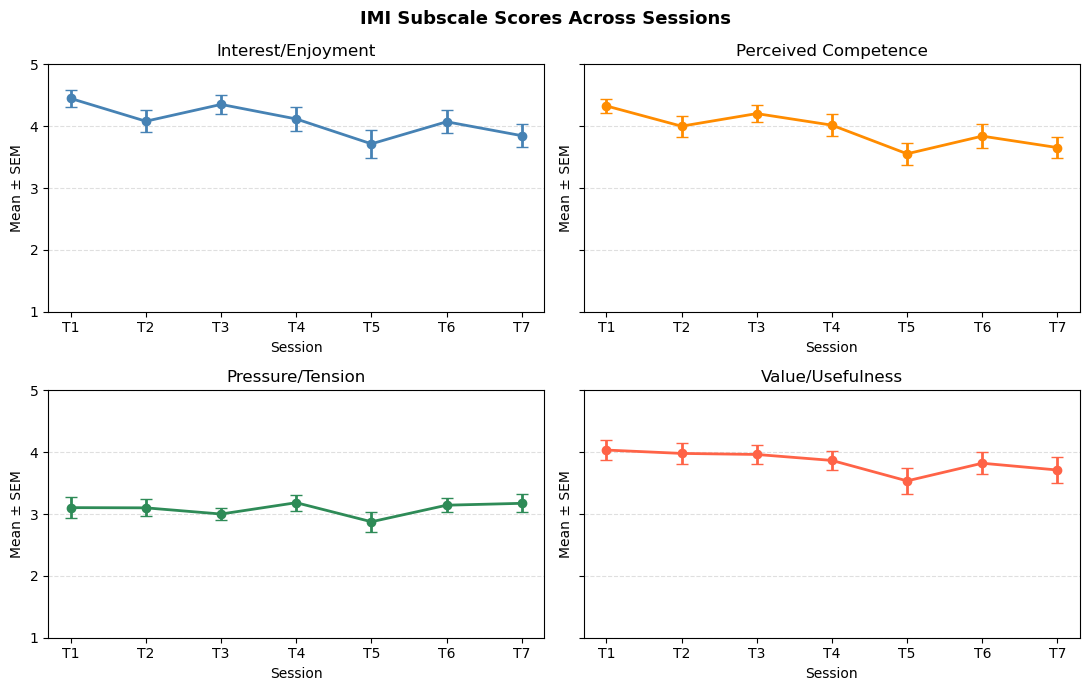

In [10]:
colors = ["steelblue", "darkorange", "seagreen", "tomato"]

# Build panel titles with question numbers derived from SUBSCALES keys
def panel_title(subscale, items):
    q_nums = ", ".join(f"Q{col.split('_')[1]}" for col in items)
    return f"{subscale}\n({q_nums})"

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
axes = axes.flatten()

for ax, (subscale, stats), color in zip(axes, subscale_stats.items(), colors):
    ax.errorbar(
        stats.index.astype(str),
        stats["Mean"],
        yerr=stats["SEM"],
        marker="o", linewidth=2, capsize=4, color=color
    )
    ax.set_ylim(1, 5)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.set_title(panel_title(subscale, SUBSCALES[subscale]))
    ax.set_xlabel("Session")
    ax.set_ylabel("Mean ± SEM")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle("Intrinsic Motivation Inventory: Subscale Scores Across Sessions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("images/engagement_IMI_subscales_by_timepoint.png", dpi=150)
plt.show()

## Responses per timepoint

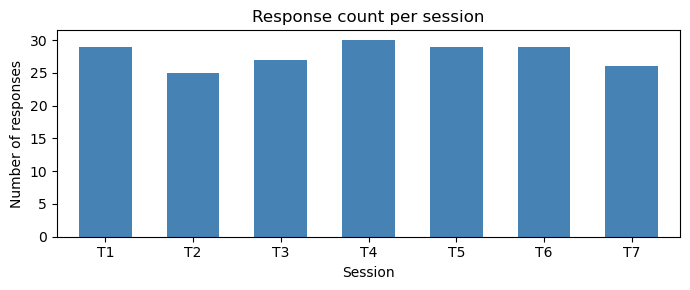

In [11]:
counts = df.groupby("Timepoint", observed=True)["Participant ID"].count()

fig, ax = plt.subplots(figsize=(7, 3))
counts.plot.bar(ax=ax, color="steelblue", width=0.6)
ax.set_xlabel("Session")
ax.set_ylabel("Number of responses")
ax.set_title("Response count per session")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Subscale score distributions per timepoint

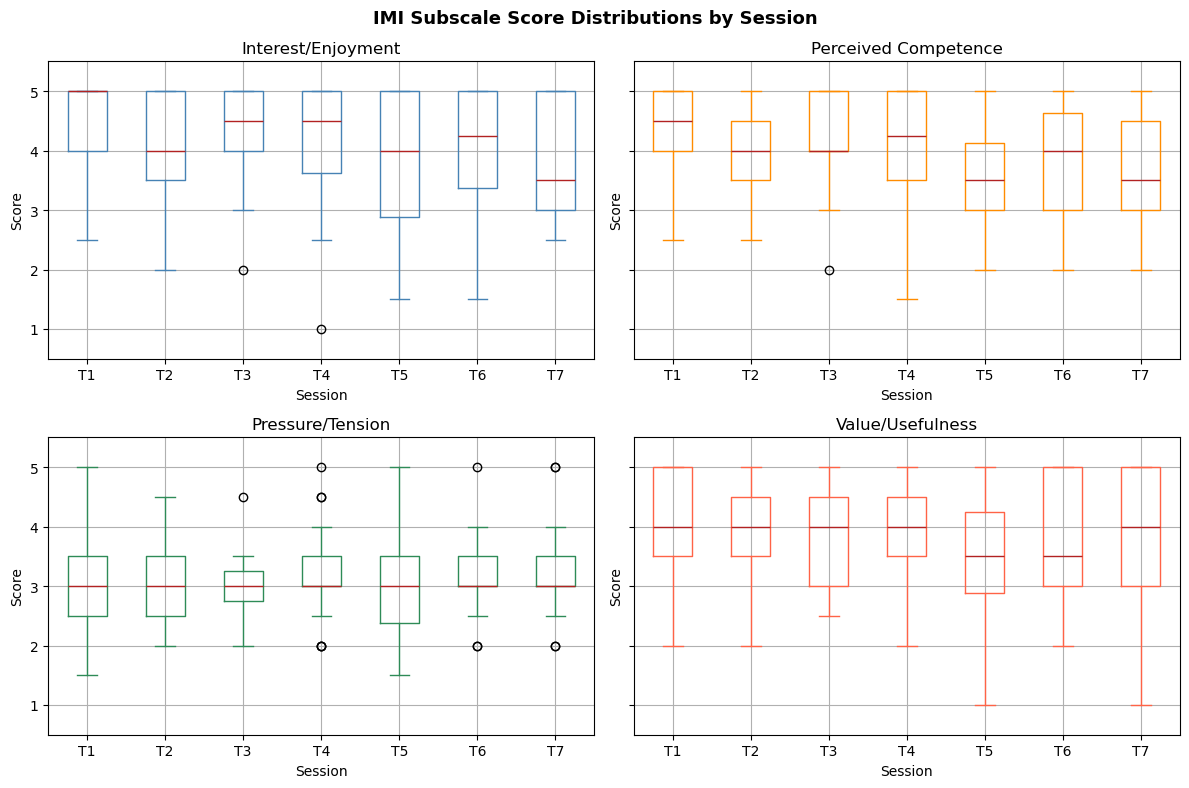

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.flatten()

for ax, (subscale, color) in zip(axes, zip(SUBSCALES.keys(), colors)):
    df.boxplot(
        column=subscale,
        by="Timepoint",
        ax=ax,
        positions=range(len(TIMEPOINT_ORDER)),
        boxprops=dict(color=color),
        medianprops=dict(color="firebrick"),
        whiskerprops=dict(color=color),
        capprops=dict(color=color),
    )
    ax.set_xticks(range(len(TIMEPOINT_ORDER)))
    ax.set_xticklabels(TIMEPOINT_ORDER)
    ax.set_ylim(0.5, 5.5)
    ax.set_title(subscale)
    ax.set_xlabel("Session")
    ax.set_ylabel("Score")
    plt.sca(ax)
    plt.title(subscale)

fig.suptitle("IMI Subscale Score Distributions by Session", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()